# Hands-on exercise: human hemoglobin

1. Download the mmCIF file from PDB (6FQF) and parse it.
2. Extract the sequence of the protein subunits and obtain the overall amino acid composition
3. Identify for each chain the residue that is closest to its corresponding iron atom
    - Remember to account for all the atoms in each residue, not only the C$\alpha$
4. Calculate the radius of gyration of the individual chains, as well as for the complete structure
    - You can use the function we defined previously
6. _(Optional)_ Compare the structure with that of hemoglobin when bound to oxygens (PDB: 1GZX)

In [1]:
# Load modules
import Bio
import numpy as np
import matplotlib.pyplot as plt

from Bio.PDB import PDBList, MMCIFParser, MMCIFIO, Superimposer
from Bio.PDB.Polypeptide import PPBuilder
from Bio.SeqUtils.ProtParam import ProteinAnalysis

## 1. Download the mmCIF file from PDB and parse it

In [2]:
# Initialize PDBList
pdbl = PDBList(server="https://files.rcsb.org")

# Download our structure
pdbl.retrieve_pdb_file('6fqf', pdir='./Data/', file_format='mmCif')

Structure exists: './Data/6fqf.cif' 


'./Data/6fqf.cif'

In [3]:
# Now we can initialize the parser and read the file
parser = MMCIFParser()
structure = parser.get_structure('6fqf', './Data/6fqf.cif')

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/Bio/PDB/StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain A is discontinuous at line 4492.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/Bio/PDB/StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain B is discontinuous at line 4535.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/Bio/PDB/StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain C is discontinuous at line 4578.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/Bio/PDB/StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain D is discontinuous at line 4621.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/Bio/PDB/StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain A is discontinuous at line 4664.
  warni

We get warnings indicating that all 4 chains are discontinuous. But if we take a closer look, we will see that this warning is triggered by the heteroatoms included in the chains.

In [4]:
# How many models do we have?
print(f'The structure has {len(structure)} model')

The structure has 1 model


In [5]:
# Print discontinuity for each chain
for chain in structure[0]:
    chain_res = list(chain.get_residues())
    for i, r in enumerate(chain_res):
        # Skip last residue
        if i == len(chain_res) - 1:
            continue

        # Check for discontinuity and print if found
        r_id = r.get_id()[1]
        next_r_id = chain_res[i+1].get_id()[1]
        if r_id != next_r_id - 1:
            print(f'Discontinuity between residues:\n{r.get_id()} and {chain_res[i+1].get_id()}')

Discontinuity between residues:
(' ', 146, ' ') and ('H_HEM', 201, ' ')
Discontinuity between residues:
('H_HEM', 201, ' ') and ('W', 301, ' ')
Discontinuity between residues:
(' ', 146, ' ') and ('H_HEM', 201, ' ')
Discontinuity between residues:
('H_HEM', 201, ' ') and ('W', 301, ' ')
Discontinuity between residues:
(' ', 146, ' ') and ('H_HEM', 201, ' ')
Discontinuity between residues:
('H_HEM', 201, ' ') and ('W', 301, ' ')
Discontinuity between residues:
(' ', 146, ' ') and ('H_HEM', 201, ' ')
Discontinuity between residues:
('H_HEM', 201, ' ') and ('W', 301, ' ')


This confirms that the actual protein chains are continuous, so we can proceed normally.

## 2. Extract the sequence of the protein subunits and obtain the overall amino acid composition

In [6]:
# Let us extract the amino acid sequence for each chain
chain_sequences = dict()
for chain in structure[0]:
    ppb = PPBuilder()
    pp = ppb.build_peptides(chain)[0]
    chain_id = chain.get_id()
    chain_sequences[chain_id] = pp.get_sequence()

# We can easily check if all the subunits have the same sequence
all_equal = True
for k in chain_sequences:
    seq_A = chain_sequences[k]
    for l in chain_sequences:
        seq_B = chain_sequences[l]
        if not seq_A == seq_B:
            all_equal = False

if all_equal:
    print('All subunits have the same sequence')
else:
    print('At least one pair of subunits has different sequences')

All subunits have the same sequence


In [7]:
# Since all subunits have the same sequence,
# we can proceed using the first one
sequence = chain_sequences['A']
seq_analysis = ProteinAnalysis(sequence)

# Let us print the amino acid percentages
print('Amino acid percentages for human hemoglobin:')
amino_acid_percent = seq_analysis.get_amino_acids_percent()
# We can sort the values for a better presentation
amino_acid_percent = dict(sorted(amino_acid_percent.items(),
                                 key=lambda x: x[1], reverse=True))   
for k in amino_acid_percent:
    print(f'{k}: {amino_acid_percent[k]}')

Amino acid percentages for human hemoglobin:
L: 0.1232876712328767
V: 0.1232876712328767
A: 0.10273972602739725
G: 0.08904109589041095
K: 0.07534246575342465
H: 0.06164383561643835
E: 0.0547945205479452
F: 0.0547945205479452
D: 0.04794520547945205
P: 0.04794520547945205
T: 0.04794520547945205
N: 0.04109589041095891
S: 0.03424657534246575
Q: 0.020547945205479454
R: 0.020547945205479454
Y: 0.020547945205479454
C: 0.0136986301369863
W: 0.0136986301369863
M: 0.00684931506849315
I: 0.0


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/Bio/SeqUtils/ProtParam.py:106: BiopythonDeprecationWarning: The get_amino_acids_percent method has been deprecated and will likely be removed from Biopython in the near future. Please use the amino_acids_percent attribute instead.
  warnings.warn(


## 3. Identify for each chain the residue that is closest to its corresponding iron atom

In [8]:
# First we need to identify the coordinates of the iron atom
# for each chain
chain_irons = dict()
for chain in structure[0]:
    for r in chain.get_residues():
        if r.get_id()[0] == 'H_HEM':
            for atom in r.get_atoms():
                if atom.get_id() == 'FE':
                    chain_irons[chain.get_id()] = atom.get_coord()

In [9]:
# Now, for each chain, we can find the residue closest to 
# the corresponding iron atom
chain_res_close2iron = dict()
for chain in structure[0]:
    closest_res = None
    closest_dist = 1e5
    for r in chain.get_residues():
        # Skip residues that do not correspond to 
        # the protein
        if r.get_id()[0] in ['H_HEM', 'W']:
            continue
            
        # Get the distances from all atoms of the residue
        res_dist = []
        for a in r.get_atoms():
            x = a.get_coord()
            d = np.linalg.norm(x - chain_irons[chain.get_id()])
            res_dist.append(d)

        # Keep shortest distance
        res_dist = np.min(res_dist)

        # Compare to current closest and replace if needed
        if res_dist < closest_dist:
            closest_res = r
            closest_dist = res_dist

    # Save the closest residue of the chain
    chain_res_close2iron[chain.get_id()] = {
        'res': closest_res, 'dist': closest_dist}

In [10]:
# Finally, we can print the closest residues
print('Residues closes to Fe for each chain:')
for chain_id in chain_res_close2iron:
    print(chain_res_close2iron[chain_id])

Residues closes to Fe for each chain:
{'res': <Residue HIS het=  resseq=92 icode= >, 'dist': 2.1153526}
{'res': <Residue HIS het=  resseq=92 icode= >, 'dist': 2.1003458}
{'res': <Residue HIS het=  resseq=92 icode= >, 'dist': 2.066316}
{'res': <Residue HIS het=  resseq=92 icode= >, 'dist': 2.181626}


We can corroborate that this is correct by using the PDB structure visualizer

## 4. Calculate the radius of gyration of the individual chains, as well as for the complete structure

In [11]:
# Let us use the function we defined previously
def get_radius_of_gyration(mdl):
    # Get residues, excluding water, ligands and ions
    res = [r for r in mdl.get_residues() if r.get_id()[0] == ' ']

    # Extract coordinates from the CA of each residue
    X = np.array([r['CA'].get_coord() for r in res])

    # Get the geometric center of mass
    r_cm = np.mean(X, axis=0)
    print("center of mass:", r_cm)
    # Calculate the radius of gyration and return
    R2_G = np.mean(np.square(np.linalg.norm(X - r_cm, axis=0)))
    return R2_G

In [12]:
# Calculate the mean radius of gyration for the individual chains
R_G_chains = [
    get_radius_of_gyration(chain) for chain in structure[0]
]
R_G_chain_mean = np.mean(R_G_chains)
print(f'Mean subunit radius of gyration: R_G = {R_G_chain_mean:.2e} A^2')

center of mass: [16.614523 16.48972  10.314861]
center of mass: [ 22.153946 -11.689551  22.922478]
center of mass: [ 0.1658356 -4.062944  27.780087 ]
center of mass: [ 6.7972    -0.7089591 -2.6431508]
Mean subunit radius of gyration: R_G = 1.07e+04 A^2


In [13]:
# Calculate the radius of gyration for the entire model
R_G_model = get_radius_of_gyration(structure[0])
print(f'Radius of gyration of the whole structure: R_G = {R_G_model:.2e} A^2')

center of mass: [1.1432875e+01 7.0653027e-03 1.4593568e+01]
Radius of gyration of the whole structure: R_G = 1.05e+05 A^2


## 5. (Optional) Compare the structure with that of hemoglobin when bound to oxygens (PDB: 1GZX)

### Downloading and parsing the structure

In [14]:
# First, we have to dowload the 1GZX entry and parse the file
pdbl.retrieve_pdb_file('1gzx', pdir='./Data/', file_format='mmCif')

Structure exists: './Data/1gzx.cif' 


'./Data/1gzx.cif'

In [15]:
parser = MMCIFParser()
structure_2 = parser.get_structure('1gzx', './Data/1gzx.cif')

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/Bio/PDB/StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain A is discontinuous at line 4384.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/Bio/PDB/StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain B is discontinuous at line 4429.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/Bio/PDB/StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain C is discontinuous at line 4474.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/Bio/PDB/StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain D is discontinuous at line 4519.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/Bio/PDB/StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain A is discontinuous at line 4564.
  warni

In [16]:
# Check if the discontinuities are the same
for chain in structure_2[0]:
    chain_res = list(chain.get_residues())
    for i, r in enumerate(chain_res):
        # Skip last residue
        if i == len(chain_res) - 1:
            continue

        # Check for discontinuity and print if found
        r_id = r.get_id()[1]
        next_r_id = chain_res[i+1].get_id()[1]
        if r_id != next_r_id - 1:
            print(f'Discontinuity between residues:\n{r.get_id()} and {chain_res[i+1].get_id()}')

Discontinuity between residues:
(' ', 141, ' ') and ('H_HEM', 1142, ' ')
Discontinuity between residues:
('H_OXY', 1143, ' ') and ('W', 2001, ' ')
Discontinuity between residues:
(' ', 289, ' ') and ('H_HEM', 1290, ' ')
Discontinuity between residues:
('H_OXY', 1291, ' ') and ('W', 2001, ' ')
Discontinuity between residues:
(' ', 541, ' ') and ('H_HEM', 1542, ' ')
Discontinuity between residues:
('H_OXY', 1543, ' ') and ('W', 2001, ' ')
Discontinuity between residues:
(' ', 689, ' ') and ('H_HEM', 1690, ' ')
Discontinuity between residues:
('H_OXY', 1691, ' ') and ('W', 2001, ' ')


We now have the $O_2$ molecule next to the HEM in the chains.

### Comparing the radius of gyration

In [17]:
# Calculate the mean radius of gyration for the individual chains
R_G_chains_2 = [
    get_radius_of_gyration(chain) for chain in structure_2[0]
]
R_G_chain_mean_2 = np.mean(R_G_chains_2)
print(f'Mean subunit radius of gyration: R_G = {R_G_chain_mean_2:.2e} A^2')

center of mass: [-10.114553  11.091895  -6.792582]
center of mass: [-31.78308     20.579226    -0.15586354]
center of mass: [-14.768865  39.66159  -20.303627]
center of mass: [-24.158447  21.855318 -34.227848]
Mean subunit radius of gyration: R_G = 1.03e+04 A^2


In [18]:
# Calculate the radius of gyration for the entire model
R_G_model_2 = get_radius_of_gyration(structure_2[0])
print(f'Radius of gyration of the whole structure: R_G = {R_G_model_2:.2e} A^2')

center of mass: [-20.341513  23.260773 -15.401721]
Radius of gyration of the whole structure: R_G = 1.08e+05 A^2


The structure bound to oxygen has a radius of gyration ~3% larger than the reference, while the individual chains have, in average, a radius of gyration ~4% lower.

### Calculating the per residue RMSD

You may notice that the structure 1GZX does not have 4 identical subunits, but rather two alpha and two beta subunits. The beta subunits are the ones found in the original structure, 6FQF. Therefore, we will only align chains B and D from the two entries. 

In [19]:
# Initialize superimposer
superimposer = Superimposer()

# Set reference model
ref_model = structure[0]
alt_model = structure_2[0]

# Get CA atoms only from B and D chains
ref_atoms = [
    res['CA'] for res in ref_model.get_residues()\
    if res.get_id()[0] == ' ' and res.get_parent().get_id() in ['B', 'D']
]
alt_atoms = [
    res['CA'] for res in alt_model.get_residues()\
    if res.get_id()[0] == ' ' and res.get_parent().get_id() in ['B', 'D']    
]

# Align the alternative atoms
superimposer.set_atoms(ref_atoms, alt_atoms)
superimposer.apply(alt_model.get_atoms())

print(f'Overall RMS value for 1GZX using 6FQF as reference (chains B and D): {superimposer.rms:.2f} A')

# Save aligned model for visualization
io = MMCIFIO()
io.set_structure(structure_2)
io.save('./Data/1gzx_aligned.cif')

Overall RMS value for 1GZX using 6FQF as reference (chains B and D): 16.70 A


In [20]:
# Now, we can estimate the RMSD for each residue
res_rmsd_B = dict()
res_rmsd_D = dict()
for chain in ref_model:
    # Skip chains A and C
    if chain.get_id() in ['A', 'C']:
        continue

    # Get alt. chain
    alt_chain = [ch for ch in alt_model if ch.id == chain.id][0]
    
    # Get ref. and alt. residues
    ref_res = [r for r in chain.get_residues() if r.get_id()[0] == ' ']
    alt_res = [r for r in alt_chain.get_residues() if r.get_id()[0] == ' ']

    # Let's perform a check to make sure that the residues are the same
    check_value = True
    for i, r in enumerate(ref_res):
        if r.get_id()[0] != alt_res[i].get_id()[0]:
            check_value = False
    print(f'Residue correspondence between structures in chain {chain.get_id()}:',
          check_value)
    
    for i, r in enumerate(ref_res):
        # Get deviation (here we only consider CA positions)
        res_deviations = alt_res[i]['CA'] - r['CA']
    
        # Calculate residue RMSD and save for each chain
        if chain.id == 'B':
            res_rmsd_B[r.id] = np.sqrt(np.mean(np.square(res_deviations)))
        else:
            res_rmsd_D[r.id] = np.sqrt(np.mean(np.square(res_deviations)))

Residue correspondence between structures in chain B: True
Residue correspondence between structures in chain D: True


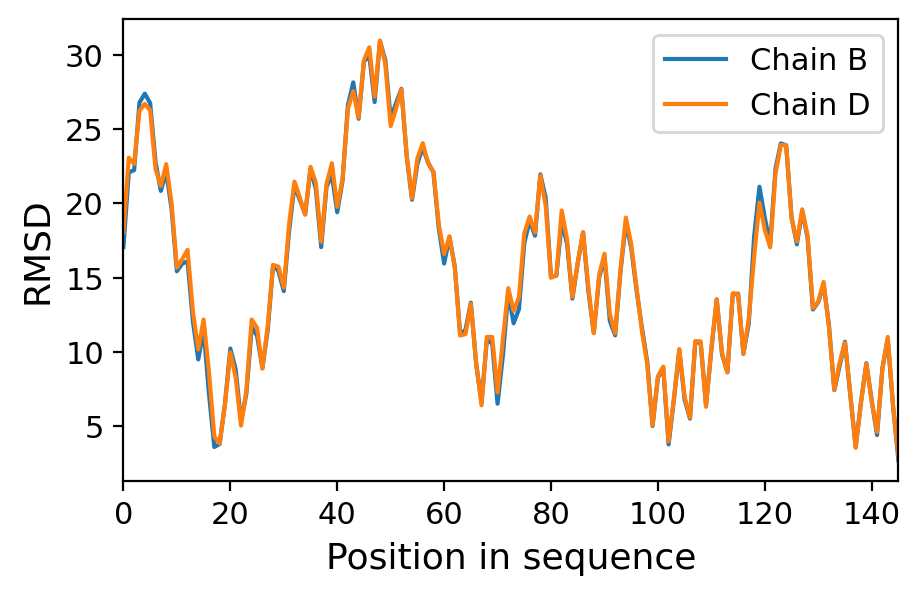

In [21]:
# Finally, we can plot the RMSD per residue
FONTSIZE = 13
fig, ax = plt.subplots(figsize=(5,3), nrows=1, ncols=1, dpi=200)

# Plots
plt.plot(res_rmsd_B.values(), label='Chain B')
plt.plot(res_rmsd_D.values(), label='Chain D')

# Labels and legend
plt.ylabel(r'RMSD', fontsize=FONTSIZE)
plt.xlabel(r'Position in sequence', fontsize=FONTSIZE)
plt.tick_params(labelsize=FONTSIZE-2)
plt.legend(fontsize=FONTSIZE-2)

# Limits
plt.xlim(left=0, right=max([len(res_rmsd_B)-1, 
                            len(res_rmsd_D)-1]))

plt.show();